In [1]:
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
import pydicom
import glob
import os
import shutil
import pandas as pd

In [187]:
# Anatomical Data / Segmentation (SOURCE)
allAnat = "E:\Documents\MTLE\LP-0001\LP-0001-01-01-01\\anatomicalData"
oneAnat = "E:\Documents\MTLE\LP-0001\LP-0001-01-01-01\\anatomicalData\\001.dcm"

# ProbesEye Data
allProbes = "E:\Documents\MTLE\LP-0001\LP-0001-01-01-01\\anatomicalProbesEye"
oneProbes = "E:\Documents\MTLE\LP-0001\LP-0001-01-01-01\\anatomicalProbesEye\\coarse.S2.dcm"

# # Temperature Data (TARGET)
allTemp = "E:\Documents\MTLE\LP-0001\LP-0001-01-01-01\\temperatureDataS2"
oneTemp = "E:\Documents\MTLE\LP-0001\LP-0001-01-01-01\\temperatureDataS2\\032.S2.dcm"

In [188]:
# # Anatomical Data / Segmentation (SOURCE)
# allAnat = "E:\Documents\MTLE\LP-0008\LP-0008-01-01-01\\anatomicalSeg"
# oneAnat = "E:\Documents\MTLE\LP-0008\LP-0008-01-01-01\\anatomicalSeg\\100.dcm"

# # ProbesEye Data
# allProbes = "E:\Documents\MTLE\LP-0008\LP-0008-01-01-01\\anatomicalProbesEye"
# oneProbes = "E:\Documents\MTLE\LP-0008\LP-0008-01-01-01\\anatomicalProbesEye\\coarse.S2.dcm"

# # Temperature Data (TARGET)
# allTemp = "E:\Documents\MTLE\LP-0008\LP-0008-01-01-01\\temperatureDataS2"
# oneTemp = "E:\Documents\MTLE\LP-0008\LP-0008-01-01-01\\temperatureDataS2\\071.S2.dcm"


In [189]:
# Load in Anatomical Data
# A file name that belongs to the series we want to read

# Read the file's meta-information without reading bulk pixel data
reader = sitk.ImageSeriesReader()
dicom_names = reader.GetGDCMSeriesFileNames(allAnat)
reader.SetFileNames(dicom_names)
data_img = reader.Execute()

print(data_img.GetSize())
data_img.GetSpacing()


(256, 256, 160)


(1.0, 1.0, 0.9999999999999984)

In [190]:
# Load in Temperature Data

# Read the file's meta-information without reading bulk pixel data
reader = sitk.ImageSeriesReader()
dicom_names = reader.GetGDCMSeriesFileNames(allTemp)
reader.SetFileNames(dicom_names)
temp_img = reader.Execute()

print(temp_img.GetSize())
temp_img.GetSpacing()


(128, 128, 79)


(2.0, 2.0, 1.0)

In [191]:
# Load in ProbesEye Data

# Read the file's meta-information without reading bulk pixel data
reader = sitk.ImageSeriesReader()
dicom_names = reader.GetGDCMSeriesFileNames(allProbes)
reader.SetFileNames(dicom_names)
probes_img = reader.Execute()

print(probes_img.GetSize())
probes_img.GetSpacing()

(128, 128, 3)


(2.0, 2.0, 5.249999738254797)

In [192]:

#%% set all  output image parameters: origin, spacing, direction, starting index, and size.
resampler = sitk.ResampleImageFilter()
resampler.SetReferenceImage(temp_img)
resampler.SetDefaultPixelValue(data_img.GetPixelIDValue())
resampler.SetSize((128, 128, 1))
resampler.SetOutputSpacing((2.0,2.0,1.0))
resampler.SetOutputOrigin(temp_img.GetOrigin())
resampler.SetOutputDirection(temp_img.GetDirection())
resampler.SetInterpolator(sitk.sitkLinear)



resampled_img = resampler.Execute(data_img)



In [193]:
def get_laser(filepath):
    
    # read the CSV file
    df = pd.read_csv(filepath)
    
    #Find the probe location from pandas dataframe 
    laser_loc_x = float(df.iloc[10][1])
    laser_loc_y = float(df.iloc[11][1])
    laser_loc_z = float(df.iloc[12][1])
    
    return (laser_loc_x, laser_loc_y, laser_loc_z)

# tester laser
laser = get_laser("E:\Documents\MTLE\LP-0001\LP-0001-01-01-01\\caseNotes.csv")



In [194]:
print("CSV laser location:", laser)
Index_laser = resampled_img.TransformPhysicalPointToContinuousIndex((laser))
print(Index_laser)


(63.51267633248914, 63.48429146669675, -0.4755148762862973) #LP-0008
(63.469083125993826, 63.53067499735519, -1.5083545018535673) #LP-0002

CSV laser location: (14.80606195, 15.85856865, 27.5923181)
(63.58810680333251, 63.42995887026059, 0.0191673505675638)


(63.469083125993826, 63.53067499735519, -1.5083545018535673)

In [195]:
# # To transform SITK Index point onto 128x128 dicom space
# def project_laser(temp_dir, laser_loc):

#     # Create transformation matrix
#     ds = pydicom.dcmread(temp_dir)
#     laser_point = np.append(np.array(laser_loc), 1)
#     Sxyz = ds[0x0020,0x0032].value
#     Xxyz = ds[0x0020,0x0037].value
#     Yxyz = ds[0x0020,0x0037].value

#     Xxyz = np.array(Xxyz[0:3])
#     Yxyz = np.array(Yxyz[3:6])

#     itri = ds[0x0028,0x0030].value
#     jtri = ds[0x0028,0x0030].value

#     # print("point:", laser_point[0:3])
#     # print("Sxyz:",Sxyz)
#     # print("Xxyz:",Xxyz)
#     # print("Yxyz:",Yxyz)
#     # print("itri:",2)

#     trans = np.array([[Xxyz[0]*2, Yxyz[0]*2, 0, Sxyz[0]],
#                     [Xxyz[1]*2, Yxyz[1]*2, 0, Sxyz[1]],
#                     [Xxyz[2]*2, Yxyz[2]*2, 0, Sxyz[2]],
#                     [0, 0, 0, 1]]  )


#     trans_mat = np.linalg.pinv(trans)
#     new_laser = np.dot(trans,laser_point)

#     new_laser = new_laser[:-1]

#     return new_laser

# project_laser(oneTemp, physicalPoint_laser)

In [196]:
print("temp_img")
print("data_img")
print("probes_img")
print("resampled_img")
print()
print("Sizes:")
print(temp_img.GetSize())
print(data_img.GetSize())
print(probes_img.GetSize())
print(resampled_img.GetSize())

print("Direction:")
print(temp_img.GetDirection())
print(data_img.GetDirection())
print(probes_img.GetDirection())
print(resampled_img.GetDirection())

print("Origin:")
print(temp_img.GetOrigin())
print(data_img.GetOrigin())
print(probes_img.GetOrigin())
print(resampled_img.GetOrigin())


print("Spacing:")
print(temp_img.GetSpacing())
print(data_img.GetSpacing())
print(probes_img.GetSpacing())
print(resampled_img.GetSpacing())

temp_img
data_img
probes_img
resampled_img

Sizes:
(128, 128, 79)
(256, 256, 160)
(128, 128, 3)
(128, 128, 1)
Direction:
(0.9572716758259795, 0.18382109648024186, 0.2232504045911724, -0.2891901427456346, 0.6084803201578172, 0.738999838511078, 2.829528291960375e-07, -0.7719854302183697, 0.6356402249153826)
(1.0, 2.0510299999999875e-10, -2.0342896142318238e-16, -1.9056795263586889e-10, 0.9291325695805045, -0.36974676218288777, -7.583598115152273e-11, 0.36974676218288777, 0.9291325695805045)
(0.9572716758259809, 0.1838210964802344, 0.22325040459117335, -0.2891901427456305, 0.6084803201578116, 0.7389998385110849, 2.8295282566980454e-07, -0.7719854302183767, 0.6356402249153749)
(0.9572716758259795, 0.18382109648024186, 0.2232504045911724, -0.2891901427456346, 0.6084803201578172, 0.738999838511078, 2.829528291960375e-07, -0.7719854302183697, 0.6356402249153826)
Origin:
(-130.25993347168, -24.56925201416, 125.514106750488)
(-137.08101370576, -80.229305069501, -70.251024581109)
(-131.432006835

In [197]:
# source_folder = "E:\Documents\MTLE\LP-0003\LP-0001-01-01-01\\temperatureData"

# destination_folder = source_folder.replace("temperatureData", "temperatureDataS2")
# if not os.path.exists(destination_folder):
#     os.makedirs(destination_folder)

# for root, dirs, files in os.walk(source_folder):
#     for file in files:
#         if 'S2' in file:
#             source_path = os.path.join(root, file)
#             destination_path = os.path.join(destination_folder, file)
#             shutil.copy(source_path, destination_path)

In [198]:
# ds = pydicom.dcmread("E:\Documents\MTLE\LP-0001\LP-0001-01-01-01\\temperatureDataS2\\002.S2.dcm")
# # ds = pydicom.dcmread("E:\Documents\MTLE\LP-0001\LP-0001-01-01-01\\anatomicalData\\010.dcm")
# laser_point = np.array([14.80606195, 15.85856865, 27.5923181, 1])
# Sxyz = ds[0x0020,0x0032].value
# Xxyz = ds[0x0020,0x0037].value
# Yxyz = ds[0x0020,0x0037].value

# Xxyz = np.array(Xxyz[0:3])
# Yxyz = np.array(Yxyz[3:6])

# itri = ds[0x0028,0x0030].value
# jtri = ds[0x0028,0x0030].value

# print("point:", laser_point[0:3])
# print("Sxyz:",Sxyz)
# print("Xxyz:",Xxyz)
# print("Yxyz:",Yxyz)
# print("itri:",2)

# # np.array([[Xxyz[0]*2, Yxyz[0]*2, 0, Sxyz[0]], [Xxyz[1]*2, Yxyz[1]*2, 0, Sxyz[1]], ])

# trans = np.array([[Xxyz[0]*2, Yxyz[0]*2, 0, Sxyz[0]],
#                   [Xxyz[1]*2, Yxyz[1]*2, 0, Sxyz[1]],
#                   [Xxyz[2]*2, Yxyz[2]*2, 0, Sxyz[2]],
#                   [0, 0, 0, 1]]  )


# trans_mat = np.linalg.pinv(trans)
# new_laser = np.dot(trans_mat,laser_point)

# new_laser = new_laser[:-1]
# print(new_laser)





# # writer = sitk.ImageFileWriter()
# # writer.SetFileName(outputImageFileName)
# # writer.Execute(seg_img)

In [199]:
# def create_normal_plane(second_slice_path):
#     ds = pydicom.dcmread(second_slice_path)
#     #extract image orientation
#     Image_orientation_1 = ds[0x0020,0x0037].value
#     lst_image_orientation = list(Image_orientation_1)
#     #make it as two vectors for rows and columns
#     row_vector = np.array(lst_image_orientation[0:3])
#     print("row_vector:", row_vector)
#     column_vector = np.array(lst_image_orientation[3:6])
#     print("column_vector: ", column_vector)

#     row_vector = np.append(row_vector, 1)
#     column_vector = np.append(column_vector, 1)
#     row_vector = np.dot(trans_mat,row_vector)
#     column_vector = np.dot(trans_mat,column_vector)
#     row_vector = np.delete(row_vector, 3)
#     column_vector = np.delete(column_vector, 3)

#     #normal plane computed as the cross-product of the row and column vectors
#     normal_plane = np.cross(row_vector,column_vector)
#     print("normal_plane: ", normal_plane)
#     return normal_plane

# # second_slice = r"E:\MRgLITT Data\new data\2021-12-21\MTLE-2.2DTP\LP-0001\LP-0001-01-01-01\anatomicalProbesEye\coarse.S2.dcm"
# second_slice = r"E:\Documents\\MTLE\\LP-0001\\LP-0001-01-01-01\\temperatureDataS2\\002.S2.dcm"
# normal_plane = create_normal_plane(second_slice)

In [200]:
# def project(plane_point, plane_normal, point):
   
#     v = point - plane_point
#     dist = np.dot(v, plane_normal)
#     projected_point = point - dist * plane_normal
#     return projected_point

# laser_onplane_1 = project(lst_image_position, normal_plane, new_laser)
# print("Before intersection: ", new_laser)
# print("Laser intersection 1: ", laser_onplane_1)

In [201]:
Index_laser

(63.58810680333251, 63.42995887026059, 0.0191673505675638)

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 195 196 197 199
 200 201 202 203 204 205 206 207 208 211 212 213 214 215 216 220 223 224
 229 231 233 234 236 237 238 239 242 244 246 247 248 249 255 259 261 265
 267 272 274 278 280 282 283 284 289 290 294 295 29

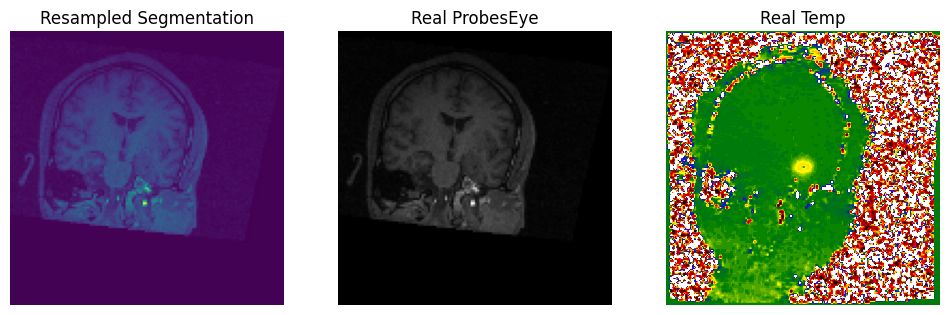

In [202]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
colors_1=["white", "darkmagenta","blue","green","yellow","orange","red", "black"]
nodes_1 = [0.0, 0.04, 0.078, 0.14, 0.17, 0.23, 0.34, 1.0]
Monteris_cmap = LinearSegmentedColormap.from_list("mycmap", list(zip(nodes_1, colors_1)))
# colors = ['black', 'purple', 'orange', 'firebrick']
# values = [0, 1/3, 2/3, 1]
# labels = ['CSF', 'GM', 'WM']
# custom_colormap = LinearSegmentedColormap.from_list("mycmap", list(zip(values, colors)))

colors = ['black', 'orange', 'purple']
integer_values = [0, 1, 2]
labels = ['CSF', 'Brain Matter']

# Create the custom colormap
custom_colormap = ListedColormap(colors)

import pydicom



slice_image = resampled_img[:, :,0]
slice_array = sitk.GetArrayFromImage(slice_image)
print(np.unique(slice_array))

# real_probes = pydicom.dcmread(oneProbes)
# real_temp = pydicom.dcmread(oneTemp)
# probes_array = real_probes.pixel_array
# temp_array = real_temp.pixel_array

probes_array = sitk.GetArrayFromImage(probes_img)
probes_slice = probes_array[1,:,:]

temp_array = sitk.GetArrayFromImage(temp_img)
temp_slice = temp_array[31,:,:]


plt.figure(figsize=(12, 6))  # Set the figure size

plt.subplot(1, 3, 1)
# plt.imshow(slice_array, cmap=custom_colormap, vmin=0, vmax=max(integer_values))
plt.imshow(slice_array)
plt.title("Resampled Segmentation")
plt.axis('off')
# legend_elements = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=8, label=label)
#                     for label, color in zip(labels, colors[1:])]
# plt.legend(handles=legend_elements, loc='center right', bbox_to_anchor = (0.6,0.2))
# plt.scatter(Index_laser[0], Index_laser[1], color='red', s=5)

plt.subplot(1, 3, 2)
plt.imshow(probes_slice, cmap='gray')
plt.title("Real ProbesEye")
plt.axis('off')
# plt.scatter(Index_laser[0], Index_laser[1], color='green', s=5)

plt.subplot(1, 3, 3)
plt.imshow(temp_slice, cmap=Monteris_cmap,vmin=0, vmax=255)
plt.title("Real Temp")
plt.axis('off')
# plt.scatter(Index_laser[0], 64, color='red', s=5)

# (152, 82, 149)
plt.show()

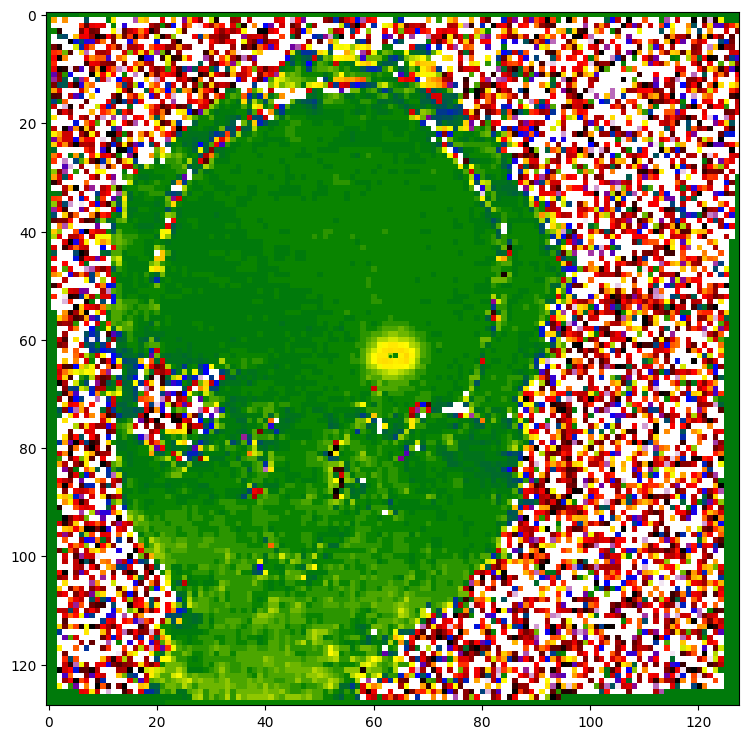

In [203]:

plt.figure(figsize=(18, 9))
plt.imshow(temp_slice, cmap=Monteris_cmap,vmin=0, vmax=255)
# plt.imshow(slice_array, cmap=custom_colormap, interpolation='none')
plt.scatter(63, 63, color='green', s=2)
# plt.scatter(64, 64, color='green', s=2)


# writer = sitk.ImageFileWriter()
# writer.SetFileName(outputImageFileName)
# writer.Execute(seg_img)

In [204]:
# import math

# segmentation_full = slice_array
# # print(segmentation_full)
# new_laser = np.array(Index_laser)


# # function parameters
# segmentation_full = segmentation_full
# boxSize = 51
# laser = np.round(new_laser)
# print(laser)

# laser = [64,63]




# left = (laser[0] - 25.5)
# right = (laser[0] + 25.5)
# top = (laser[1] + 25.5)
# bottom = (laser[1] - 25.5)

# print(right,left,bottom,top)

# boxWidth = (right - left)
# boxHeight = (bottom - top)

# print(boxWidth)
# print(boxHeight)

# if boxWidth % 2 == 0:
#     boxWidth+=1 
# if boxHeight % 2 == 0:
#     boxHeight+=1 

# print(boxWidth)
# print(boxHeight)

# # Account for even center so that laser is always in the middle pixel
# # if (left % 2) == 0 or(right % 2) == 0:
# #     left -= 1
# #     right += 1
# # if (top % 2) == 0 or(bottom % 2) == 0:
# #     top += 1
# #     bottom -= 1

# print("Left, Right, Top, Bottom:", left,right,bottom,top)

# left = round(left)
# right = round(right)
# top = round(top)
# bottom = round(bottom)

# print("Left, Right, Top, Bottom:", left,right,bottom,top)

# # Define the region to crop
# region = [left, top, 0]  # Start index (left, top) at slice 0
# size = [right - left, bottom - top, 0]  # Size of the cropped region

# # crop the image
# segmentation_cropped = segmentation_full[left:right, bottom:top]

# np.unique(segmentation_cropped)

# # cropped_image = image.crop((left, upper, right, lower)

# # 38 88 38 90
# # 38 90 38 88

In [205]:
# LP-0001:
# [63.5881068 63.4299589 1.91673506e-02] => 64,63
# shifted one right

# LP-0002:
# [63.46908313 63.530675   -1.5083545 ] => 63,64
# shifted one down

# LP-0003:
# [63.34034171 63.98942571 -2.98759304] => 63,64
# shifted one down

# LP-0008:
# [63.51267633 63.48429147 -0.47551488] => 64,63
# shifted one right

# LP-0104:
# [63.49809722 63.50050719 -0.24996248] => 63,64
# shifted one down

In [206]:
import math



segmentation_full = slice_array
# print(segmentation_full)


# function parameters
segmentation_full = segmentation_full
boxSize = 51
laser = np.array(Index_laser)
print(laser)



boxWidth = round(boxSize / 1)
boxHeight = round(boxSize / 1)
# print(boxWidth)
# print(boxHeight)

if boxWidth % 2 == 0:
    boxWidth+=1 
if boxHeight % 2 == 0:
    boxHeight+=1 

# print(boxWidth)
# print(boxHeight)    

xPosition = round(laser[0] - boxWidth/2)
yPosition = round(laser[1] - boxHeight/2)

print("Raw laser:",laser[0], laser[1])
print("Rounded laser:",round(laser[0]), round(laser[1]))
print("Before shift x,y:",xPosition, yPosition)

# Compensate for one pixel shift
if round(laser[0]) == 63 and round(laser[1]) == 64: # If laser is shifted one down
    # Shift one up
    xPosition += 1
if round(laser[0]) == 64 and round(laser[1]) == 63: # If laser is shifted one right
    # Shift one left
    yPosition += 1

print("After shift x,y:",xPosition, yPosition)

print(xPosition)
print(yPosition)

# crop the image
segmentation_cropped = segmentation_full[xPosition:xPosition+boxWidth, yPosition:yPosition+boxHeight]
segmentation_cropped.shape




[6.35881068e+01 6.34299589e+01 1.91673506e-02]
Raw laser: 63.58810680333251 63.42995887026059
Rounded laser: 64 63
Before shift x,y: 38 38
After shift x,y: 38 39
38
39


(51, 51)

In [207]:
# LP-0001:
# [63.5881068 63.4299589 1.91673506e-02] => 64,63
# shifted one right

# LP-0002:
# [63.46908313 63.530675   -1.5083545 ] => 63,64
# shifted one down

# LP-0003:
# [63.34034171 63.98942571 -2.98759304] => 63,64
# shifted one down

# LP-0008:
# [63.51267633 63.48429147 -0.47551488] => 64,63
# shifted one right

# LP-0104:
# [63.49809722 63.50050719 -0.24996248] => 63,64
# shifted one down

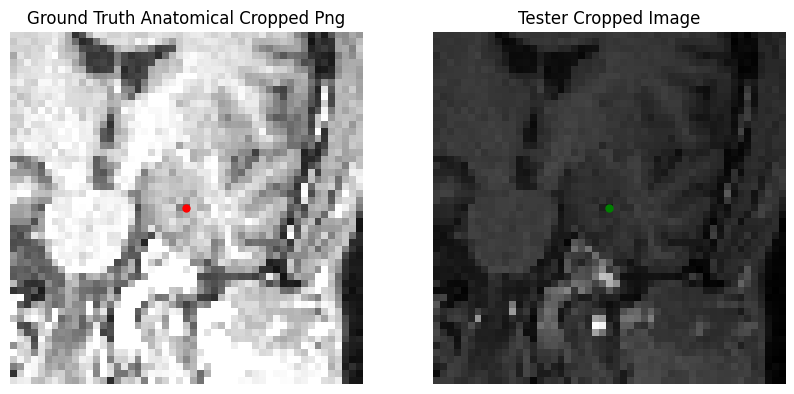

<class 'PIL.PngImagePlugin.PngImageFile'>
(51, 51, 3)


In [208]:
from PIL import Image

plt.figure(figsize=(10, 5))  # Set the figure size
# plt.subplot(1, 2, 1)
dir = "E:\Documents\MRgLITT\data\\500J\original\\anatomicalProbesEye\LP-0001-01-01-01-S2Cropped.png"
anatCropped= Image.open(dir)



plt.subplot(1, 2, 1)
plt.imshow(anatCropped)
plt.title('Ground Truth Anatomical Cropped Png')
plt.axis('off')
plt.scatter(25, 25, color='red', s=25)

# plt.show()

# plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 2)
# plt.imshow(segmentation_cropped,cmap=custom_colormap, vmin=0, vmax=max(integer_values))
plt.imshow(segmentation_cropped, cmap='gray')
plt.title('Tester Cropped Image')
plt.axis('off')  
# plt.legend(handles=legend_elements, loc='center right', bbox_to_anchor = (0.6,0.2))
plt.scatter(25, 25, color='green', s=25)

plt.show()
print(type(anatCropped))
print(np.asarray(anatCropped).shape)


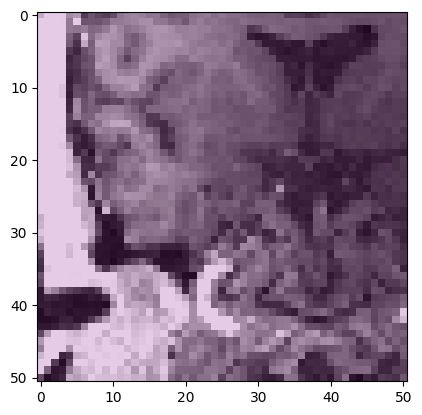

In [192]:
plt.imshow(segmentation_cropped,cmap=custom_colormap, vmin=0, vmax=max(integer_values))
plt.imshow(anatCropped, alpha = 0.8)


In [527]:
def pixel2pixel_difference_visualization(real_temp, predicted_temp):
    real_temp_arr = np.array(real_temp)
#     print("real_temp_arr", type(real_temp_arr))
    predicted_temp_arr = np.array(predicted_temp)
#     print("predicted_temp_arr", type(predicted_temp_arr))
    
    diff = predicted_temp_arr.astype(float)-real_temp_arr.astype(float)
    min_ = np.min(diff)
    max_ = np.max(diff)
    return diff, min_, max_
                        

(128, 128)

(128, 128)

In [563]:
np.array_equal(slice_array, probes_array)

False

In [521]:
diff = [slice_array == probes_array]

In [524]:
len(probes_array)

128

In [526]:
len(diff)

1